<h3><b>Data Analytics - Exercise set 4, exercise 3a.</b></h3>
<h4><b>US Unemployment dataset</b></h4>
<img src="http://srv.plab.fi/~tuomasv/data_analytics_2023_images/exercise_set_4/calendar.png" />


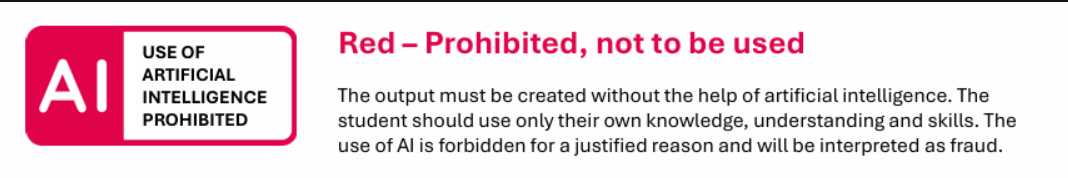

<hr /><h1>!!!!! IMPORTANT !!!!!</h1> 

<h2>Do not use generative AI in this exercise!</h2>
<b>Remember:</b> in working life, we are not allowed to freely share our data with just any generative AI, since the data is often sensitive and owned by a client. 

Generative AIs would use the data to train themselves in the future, which is a violation of regulations.
The point of this exercise set is to <b>MANUALLY</b> inspect the plots in the examples and learn how to see trends and features in the data.
 
See also the materials discussing the usage of AI in this course!
<hr />

<hr>

<b>Tip:</b> You can just click "Run All" to see the results of this notebook. Some of these exercises have some heavy plots that can take even 1 minute to produce.


<b>Remember:</b> not every dataset has interesting correlations and/or features (too much randomness or variance usually, or not enough data). Also, not each correlation implies there's a causation. Finally, not every plot is useful, that's why it's important to try multiple plots in order to "see under the hood". Typically pair plots, joint plots, regression plots, heatmaps and box plots are most useful, but there are some exceptions too.

<h3><b>Quick summary of data:</b></h3>

<p>This dataset contains unemployment rates from year 1948 to 2019 in the USA.</p>
<p>This notebook is a perfect example why pivot tables and heatmaps are so important. It also demonstrates the fantastic feature in pandas called "melt".</p>
<p>Kaggle page: <a href="https://www.kaggle.com/datasets/tunguz/us-monthly-unemployment-rate-1948-present">https://www.kaggle.com/datasets/tunguz/us-monthly-unemployment-rate-1948-present</a></p>

<h3><b>Questions for this exercise:</b></h3>
<b>Answer the questions either as code comments or as markdown. Use separate cells to write your answers.</b><br/><br/>
<li>You should see two extensive unemployment periods in the dataset. What are these years, and can find you any info by using Google on these years in US unemployment?</li>
<li>Which seaborn plots are useful in this notebook, and which are not? Why? (you can remove the unnecessary plots from this notebook if you wish too).</li>
<li>Which are more useful in this case, correlations or plots? Or are they both useful?</li>

<b>Extra questions/tasks for extra points:</b>
<li>Any other ideas about this dataset? Any ways to expand or improve the dataset and the analysis?</li>


<hr />

### Answers
1. 
- The early 1980s — The heatmap shows a dark band across 1981–1983. The joint plot also shows a distinct cluster of high values in this era.
- The late 2000s to early 2010s — Another dark band appears from 2008 onward.
**Refering the Google**
- Early 1980s (1981–1982 recession): This was triggered by the Federal Reserve's tight monetary policy under Paul Volcker to combat double-digit inflation. The result was a severe recession with the highest unemployment rate since the Great Depression. The search results confirm that the 1981–1982 recession had a peak unemployment of 10.8% . The recession was particularly brutal for manufacturing and adult men
- Late 2000s (Great Recession, 2007–2009): This was the deepest economic downturn since WWII, triggered by the collapse of the housing bubble and the global financial crisis. 

2. 
**Useful Plots**
- The pivot table heatmap (sns.heatmap(pt)): By arranging months on the y-axis and years on the x-axis, it turns a time series into a 2D visual that instantly reveals the two recessionary periods as dark vertical bands.
- The joint plot with hue='Month': This can help spot seasonal patterns within years, though with 12 months the color legend is cluttered. Still, it's more informative than the plain joint plot.
- The correlation heatmap for df2: It shows that Year and Value have a weak negative correlation, and Month has essentially no correlation with Value.

**Not Useful Plots**
- The plain joint plot (sns.jointplot(x='Year', y='Value', data=df2)): While it shows the same two clusters of high unemployment, it's essentially a scatter plot with marginal histograms. 
- The correlation heatmap for df: It's redundant and hard to interpret. The df2 version is better because it has only three variables.

3. 
- In this case, plots are far more useful than correlations.The reason is that this dataset is fundamentally a time series. 
The correlation between Year and Value is something like -0.1, which tells us almost nothing about the dramatic spikes in 1982 and 2009.

##### Extra Questions
- Add recession indicator data: This would directly connect the unemployment spikes to their economic causes and make the analysis more informative.
- Add context variables: Population, labor force participation rate, or GDP data could help explain why unemployment was high
- Use a line plot for the time series: While the heatmap is great for spotting patterns, a simple line plot of the annual average would make the magnitude and duration of the two recessions even clearer

<hr />

<h4><b>Imports and load the original dataset</b></h4>

In [1]:
# import the common data analytics modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# disable scientific notation in pandas
pd.set_option('display.float_format', lambda x: '%.2f' % x)

<h4><b>Helper functions for dataset cleaning</b></h4>

In [2]:
# helper function for pandas to convert string format month names to a corresponding number
# numbers are much more useful when it comes to heatmaps, since it puts the months in order
# note: a more neat way to do this would be use the value mapping feature in pandas
def month_to_numeric(row):
    month = row['Month']

    # map the needed month
    if month == "Jan":
        return 1
    elif month == "Feb":
        return 2
    elif month == "Feb":
        return 3
    elif month == "Mar":
        return 4
    elif month == "Apr":
        return 5
    elif month == "Jun":
        return 6
    elif month == "Jul":
        return 7
    elif month == "Aug":
        return 8
    elif month == "Sep":
        return 9
    elif month == "Oct":
        return 10
    elif month == "Nov":
        return 11
    elif month == "Dec":
        return 12

<h4><b>Processing data</b></h4>

In [ ]:
# read the dataset and create a correlation matrix
df = pd.read_csv("USUnemployment.csv")
correlations = df.corr().round(2)

# this function in pandas is called "melt", and it's one of
# the more impressive features in pandas. with loops, this would be
# a tedious operation to be done

# here's an example what melt-function does:

# original DataFrame:
# Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
# 1948,3.4,3.8,4.0,3.9,3.5,3.6,3.6,3.9,3.8,3.7,3.8,4.0
# 1949,4.3,4.7,5.0,5.3,6.1,6.2,6.7,6.8,6.6,7.9,6.4,6.6
# 1950,6.5,6.4,6.3,5.8,5.5,5.4,5.0,4.5,4.4,4.2,4.2,4.3

# after melt, the format is this:
# Year, Month,  Value
# 1948, 1,      3.4
# 1949, 1,      4.3
# 1950, 1,      6.5

# and so on. you can use the Data Viewer to compare df and df2
# remember the melt-function every time you have TimeSeries -data,
# but it's not yet very compatible for pivot table and heatmap

df2 = df.melt(id_vars=["Year"], 
             var_name="Month",
             value_name="Value")

# convert year to integer (better for heatmaps)
# also switch month string format to an integer by using the helper function (see code above)
df2['Year'] = df2['Year'].astype(int)
df2['Month'] = df2.apply(month_to_numeric, axis=1)

# create pivot table for a later heatmap
pt = df2.pivot_table(index='Month', columns='Year', values='Value')


<h4><b>seaborn plots - heatmaps for correlations matrices</b></h4>

<Axes: >

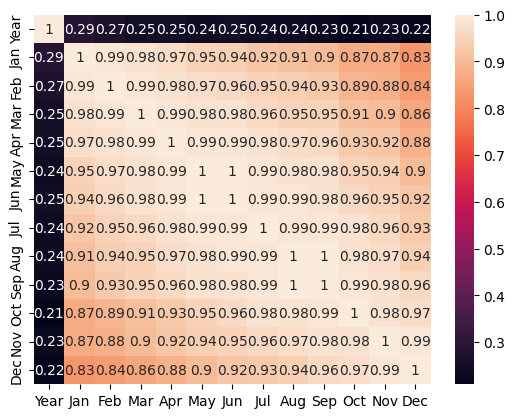

In [4]:
# basic heatmap for original data correlation matrix
sns.heatmap(correlations, annot=True)

<Axes: >

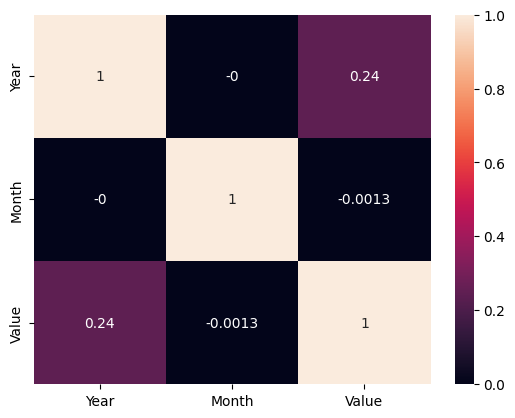

In [5]:
# basic heatmap for melted correlation matrix
sns.heatmap(df2.corr().round(4), annot=True)

<h4><b>seaborn plots - joint plots and pivot table heatmap</b></h4>

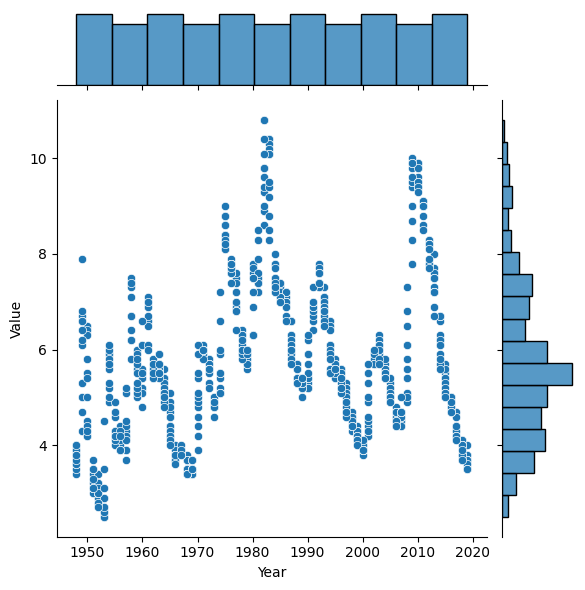

In [6]:
# basic joint plot for unemployment value and year
sns.jointplot(x='Year', y='Value', data=df2)

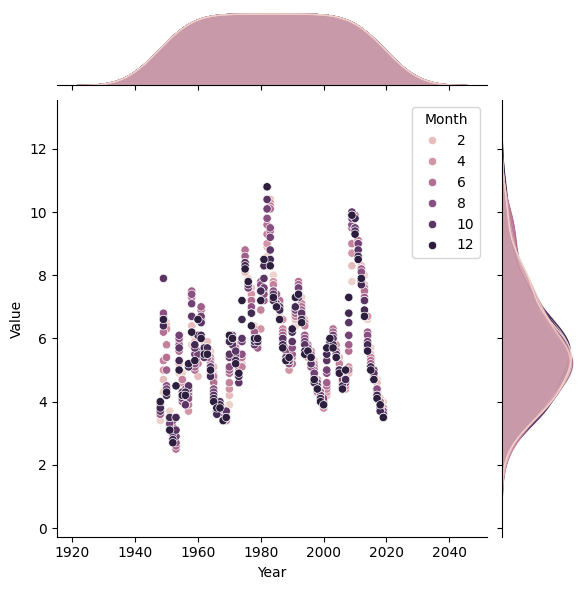

In [7]:
# basic joint plot for unemployment value and year, hue on month
sns.jointplot(x='Year', y='Value', data=df2, hue='Month')

<Axes: xlabel='Year', ylabel='Month'>

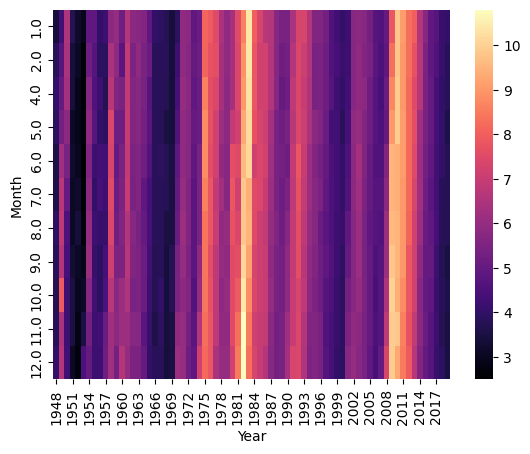

In [8]:
# heatmap for pivot table
sns.heatmap(pt, cmap='magma') 